In [1]:
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'recipes'


L'objet suivant est masqué depuis 'package:stringr':

    fixed


L'objet suivant est masqué depuis 'package:stats':

    step




In [2]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

In [3]:
dataNN<-read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
id_variable <- match('building_id', colnames(dataNN))
target_variables<-which(grepl('damage_grade',colnames(dataNN)))

In [4]:
normalizer<-layer_normalization(axis = -1L)  %>%  
adapt(as.matrix(dataNN[,-target_variables]))

In [5]:
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,])
        y[i,]<-which.max(test_data[i,target_variables])  
    }
    mylist <- list(yhat,y)
}

In [6]:
neuralmodel <- keras_model_sequential() %>% 
normalizer  %>% 
layer_dense(2, activation = 'relu') %>%
layer_dense(3,activation='softmax')

neuralmodel %>% compile(
    loss = 'categorical_crossentropy',
    optimizer = optimizer_adam(0.0001),
    metrics=c('AUC')
  )
neuralmodel

Model: "sequential"
________________________________________________________________________________
 Layer (type)                  Output Shape               Param #    Trainable  
 normalization (Normalization)  (None, 70)                141        Y          
 dense_1 (Dense)               (None, 2)                  142        Y          
 dense (Dense)                 (None, 3)                  9          Y          
Total params: 292
Trainable params: 151
Non-trainable params: 141
________________________________________________________________________________

In [8]:
set.seed(2)

nrows<-nrow(dataNN)
dataNN_idx <- sample(1:nrow(dataNN))
split <- floor(nrow(dataNN)*0.8)

train_data <- dataNN[dataNN_idx[1:split],]
test_data <- dataNN[dataNN_idx[(split+1):nrows],]

model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 30
        )

yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))
yhaty <- classConverter(yhat,test_data)
F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])

[1] 0.7378624

In [9]:
F1_Score_micro(yhaty[[1]][,],yhaty[[2]][,])

[1] 0.7378624

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 50 epochs: 0.720174372625041"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 50 epochs: 0.726906236136026"
  |==========================================                            |  60%

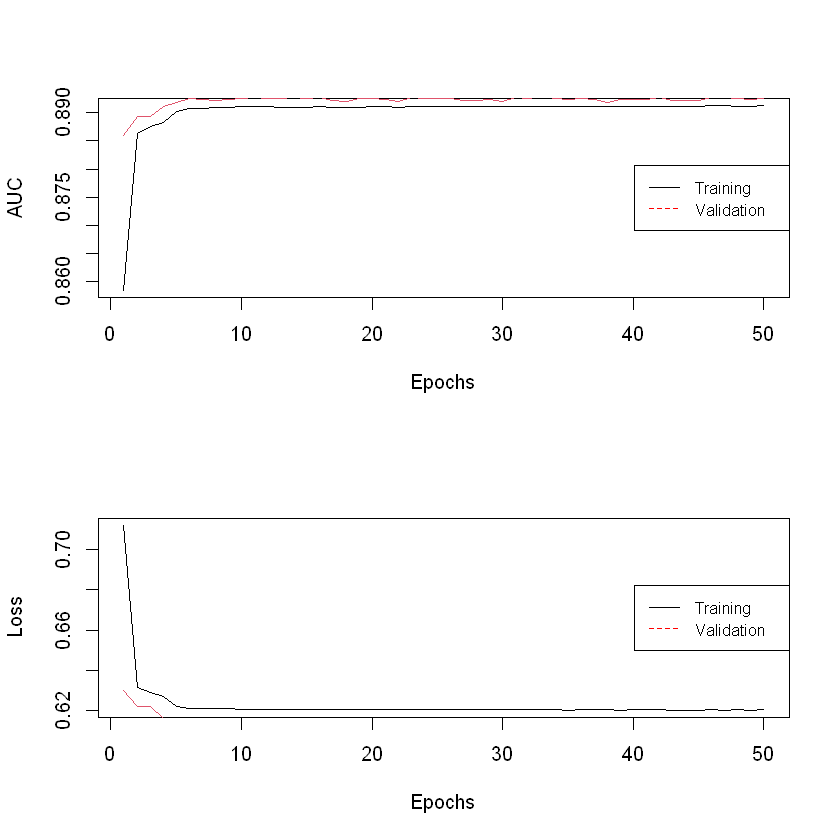

[1] "F1-Score Micro - 3 fold - 50 epochs: 0.732692938294466"
  |========================================================              |  80%

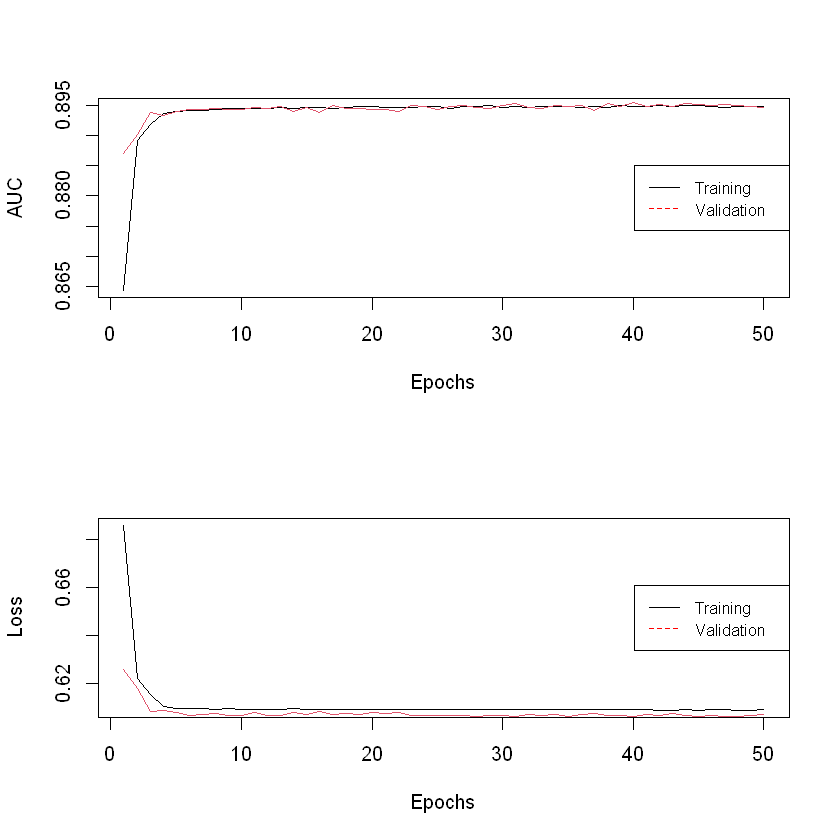

[1] "F1-Score Micro - 4 fold - 50 epochs: 0.718264760912756"
  |======================================================================| 100%

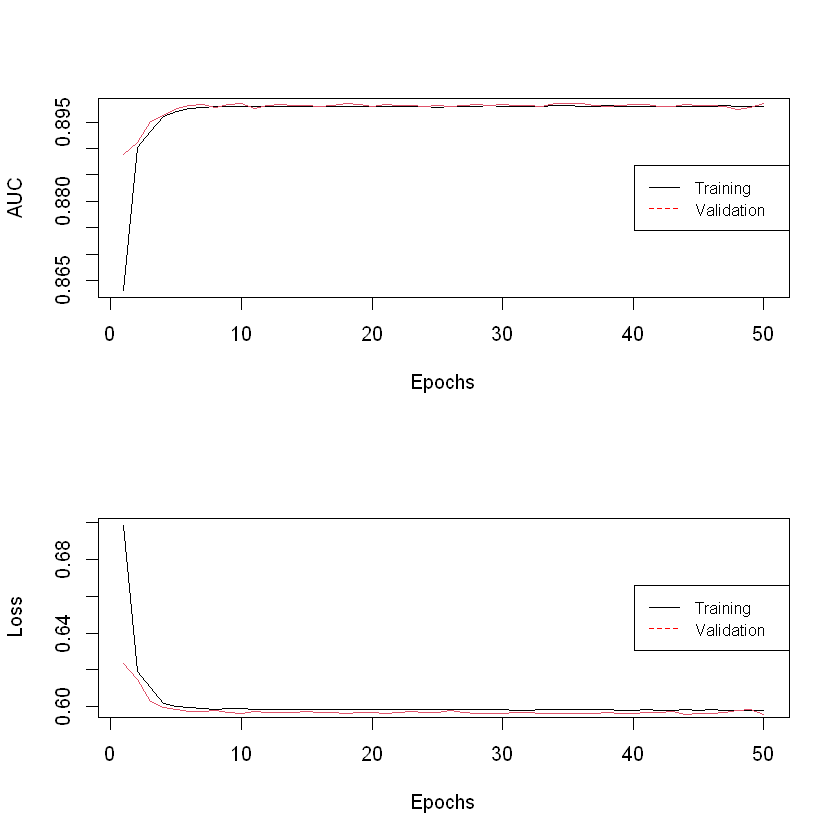

[1] "F1-Score Micro - 5 fold - 50 epochs: 0.739327533324331"


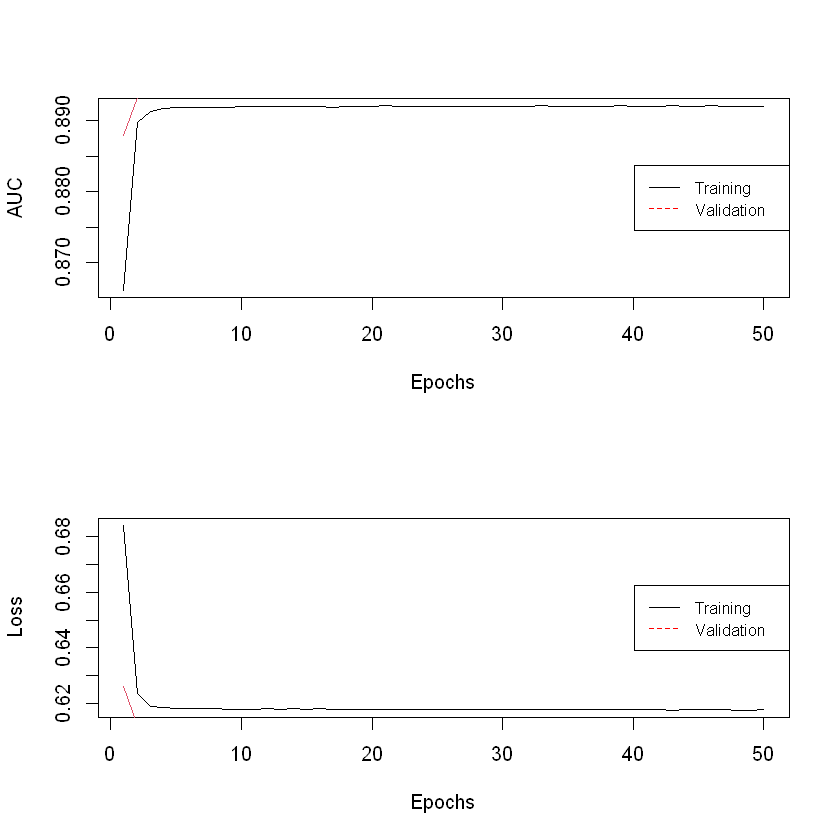

[1] "Mean F1-Score Micro: 0.727473168258524"


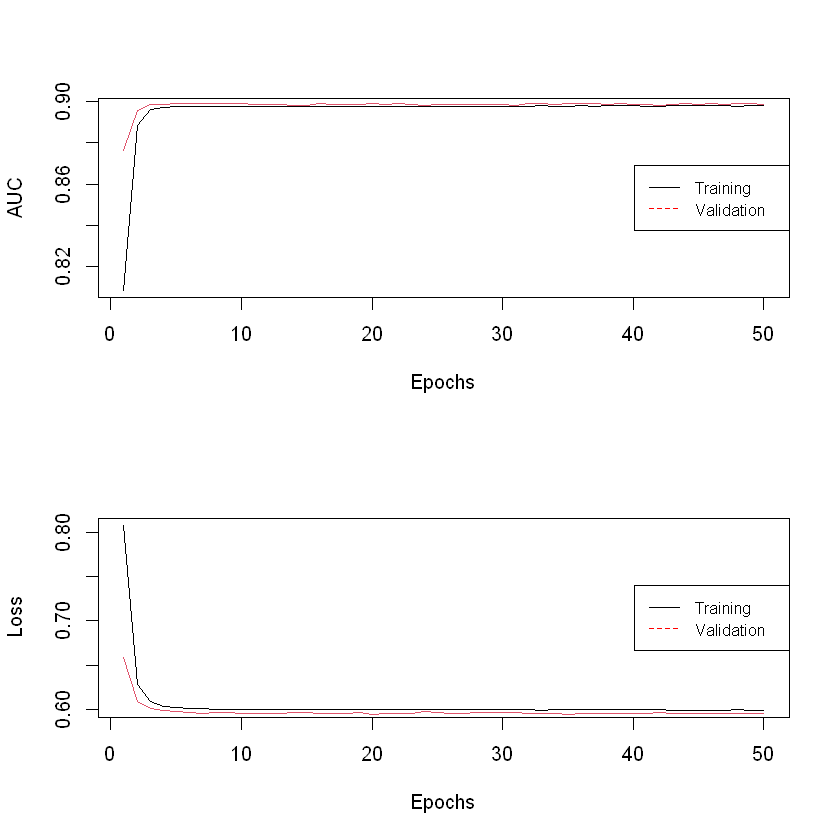

In [6]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(1, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 50 epochs: 0.737245143992439"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 50 epochs: 0.749975888741007"
  |==========================================                            |  60%

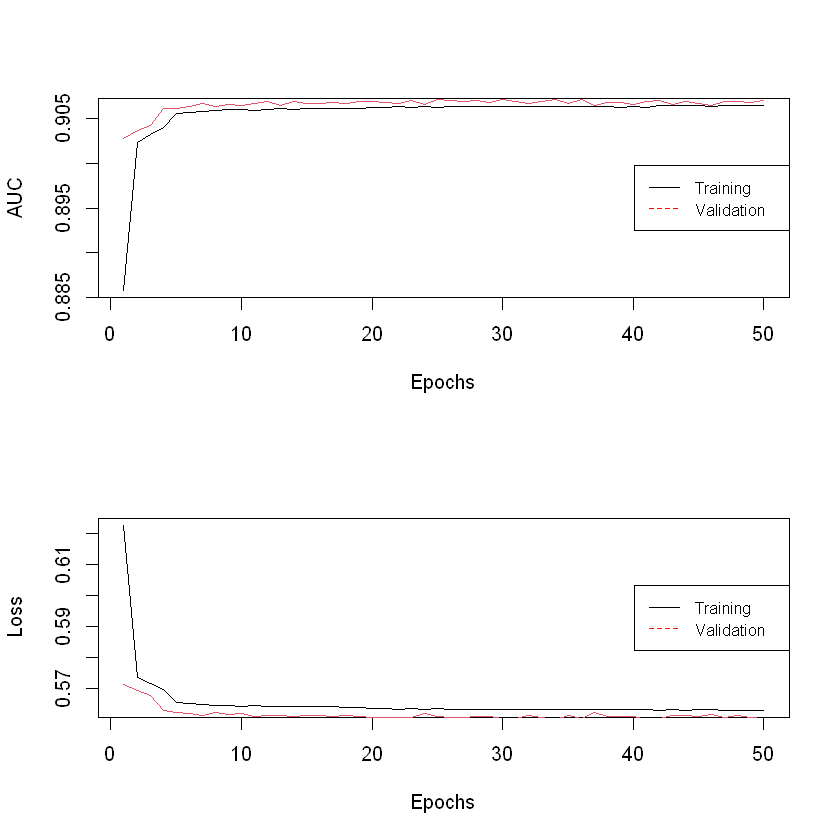

[1] "F1-Score Micro - 3 fold - 50 epochs: 0.741816638697606"
  |========================================================              |  80%

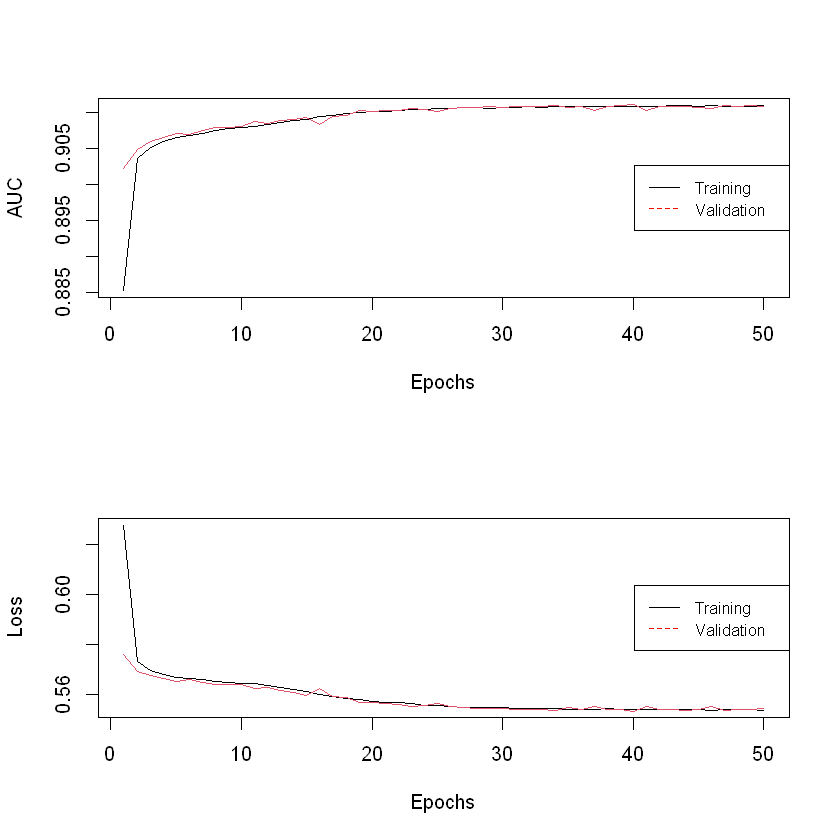

[1] "F1-Score Micro - 4 fold - 50 epochs: 0.745500839071813"
  |======================================================================| 100%

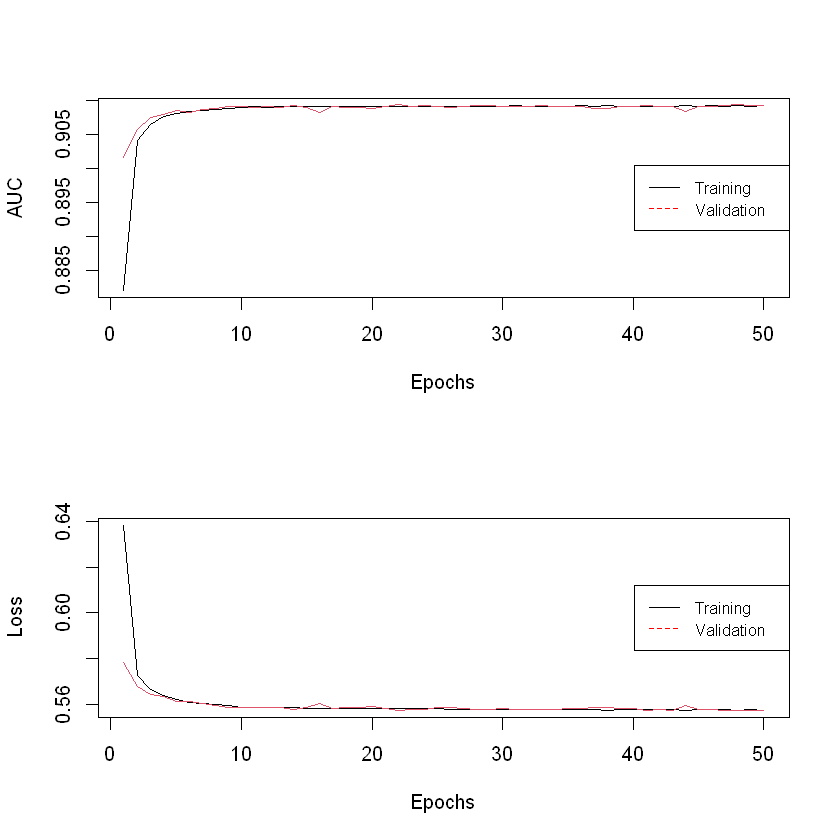

[1] "F1-Score Micro - 5 fold - 50 epochs: 0.747487412951639"


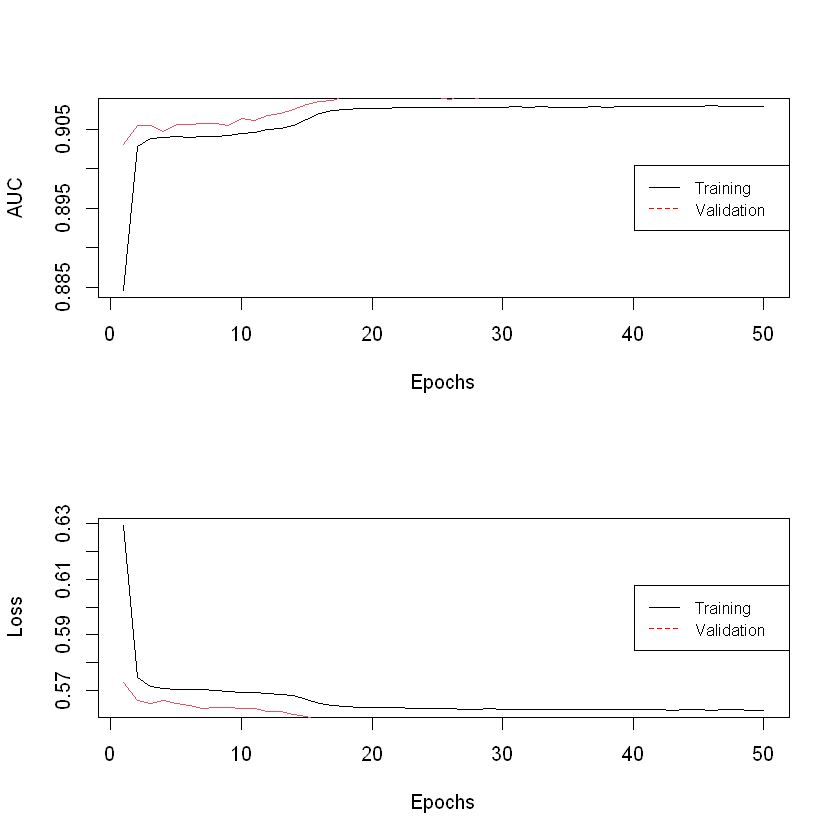

[1] "Mean F1-Score Micro: 0.744405184690901"


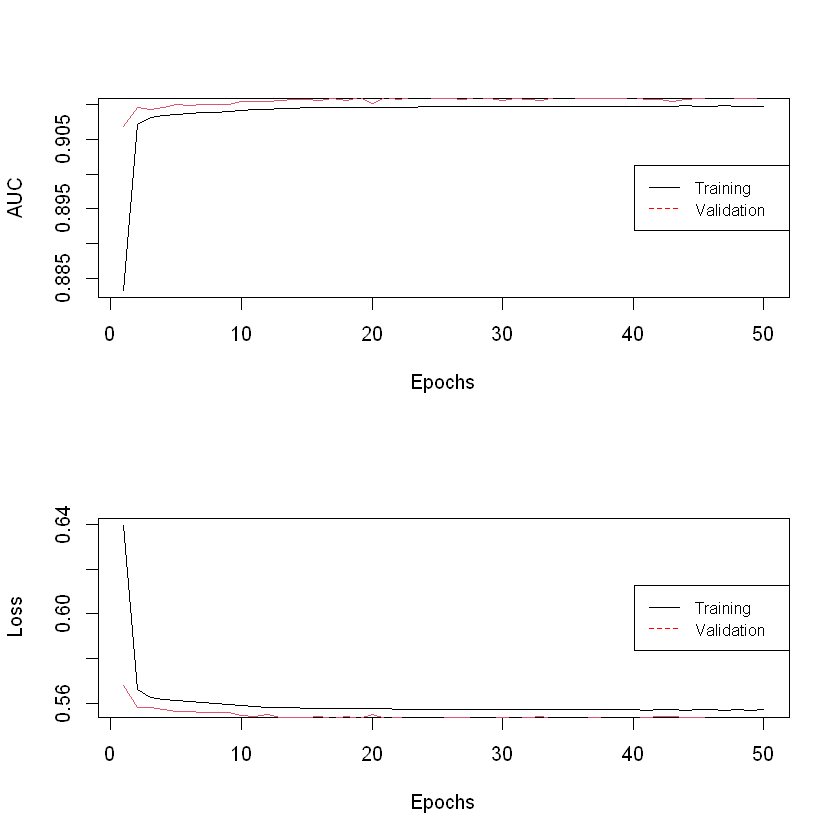

In [7]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(3, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 50 epochs: 0.756611307216018"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 50 epochs: 0.753852979187161"
  |==========================================                            |  60%

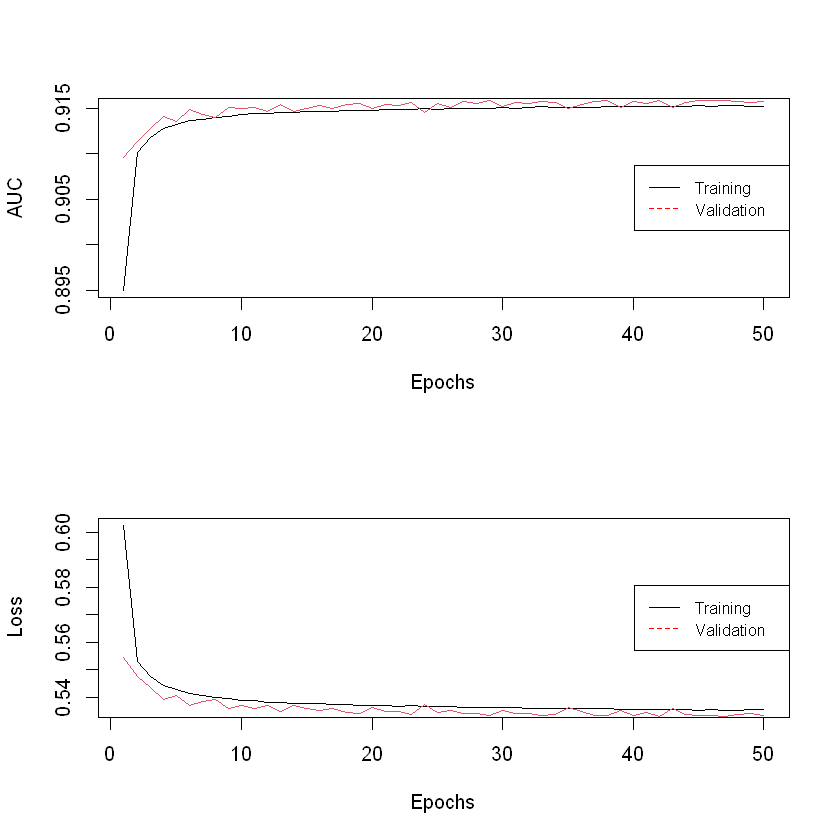

[1] "F1-Score Micro - 3 fold - 50 epochs: 0.751229674208668"
  |========================================================              |  80%

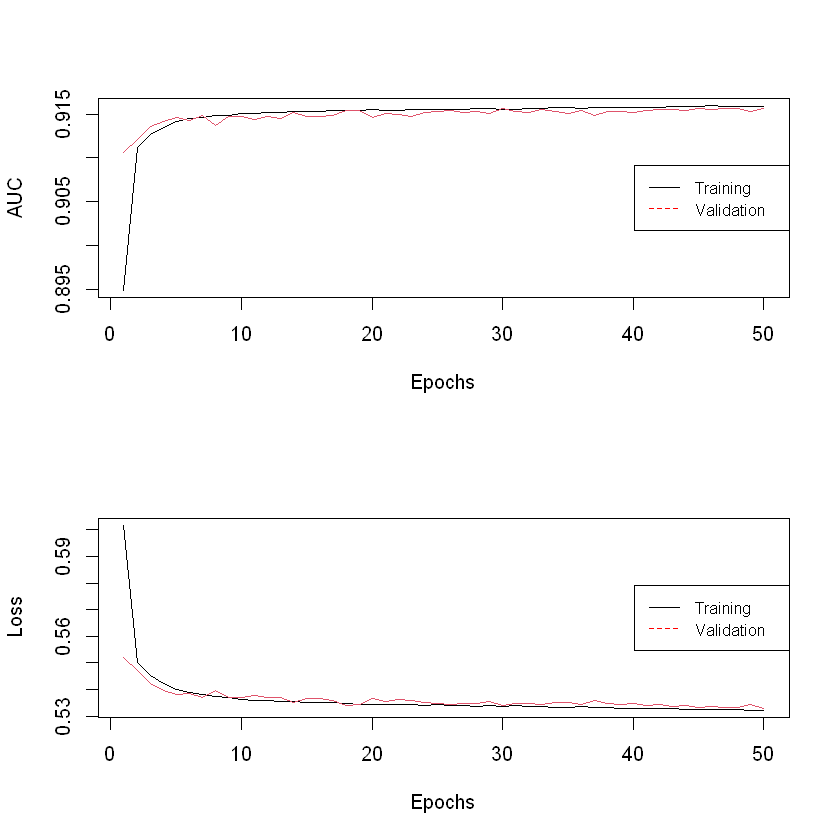

[1] "F1-Score Micro - 4 fold - 50 epochs: 0.756013347992979"
  |======================================================================| 100%

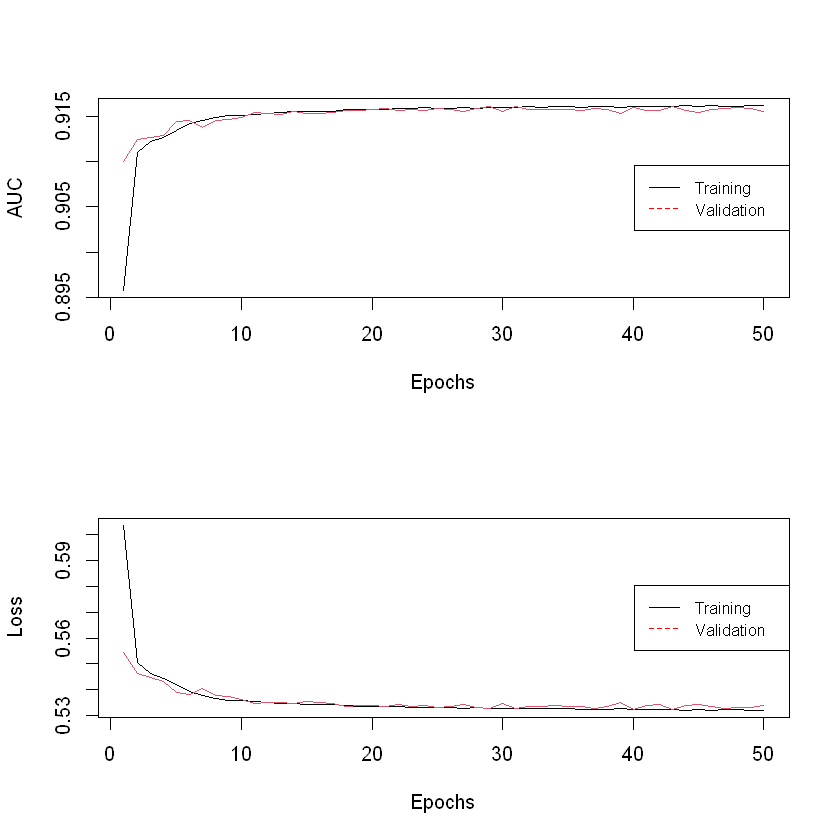

[1] "F1-Score Micro - 5 fold - 50 epochs: 0.753911147977392"


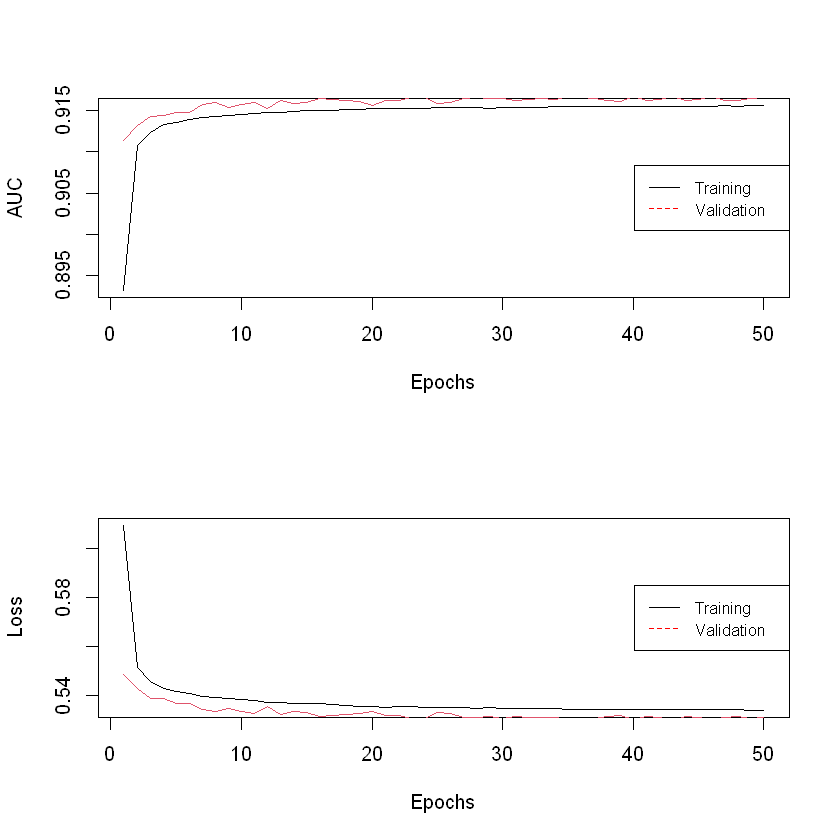

[1] "Mean F1-Score Micro: 0.754323691316444"


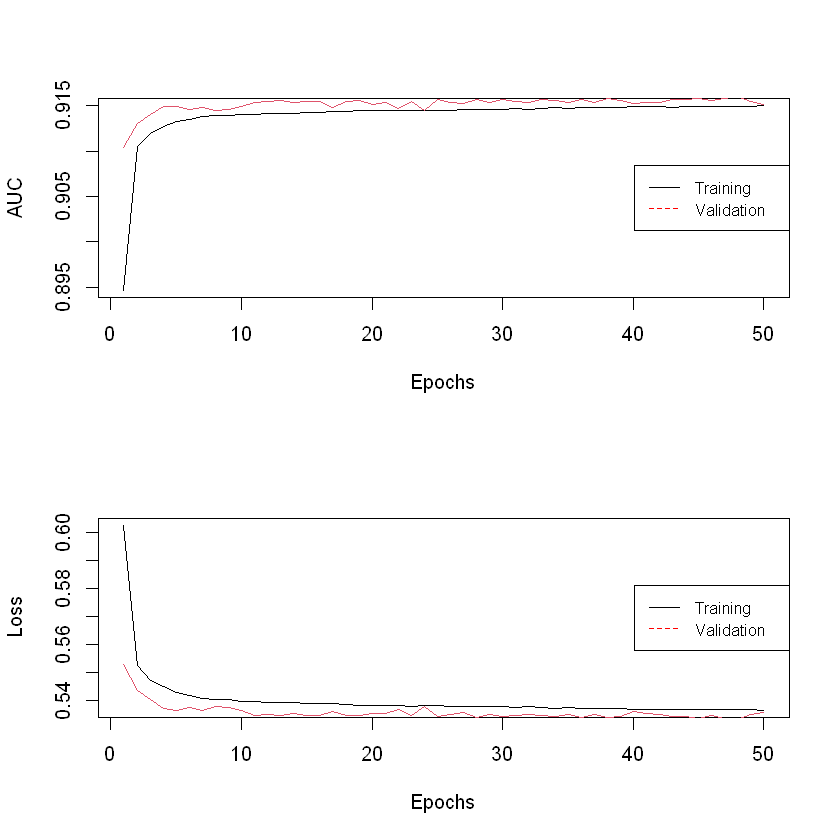

In [9]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(10, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 50 epochs: 0.570086607642305"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 50 epochs: 0.570723144879733"
  |==========================================                            |  60%

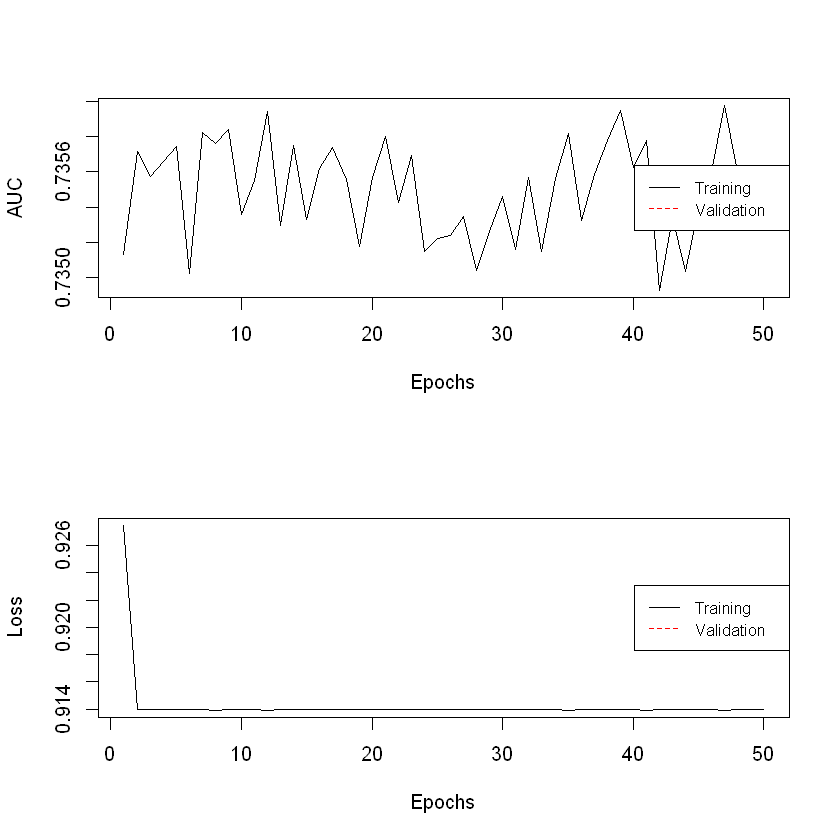

[1] "F1-Score Micro - 3 fold - 50 epochs: 0.567251123584669"
  |========================================================              |  80%

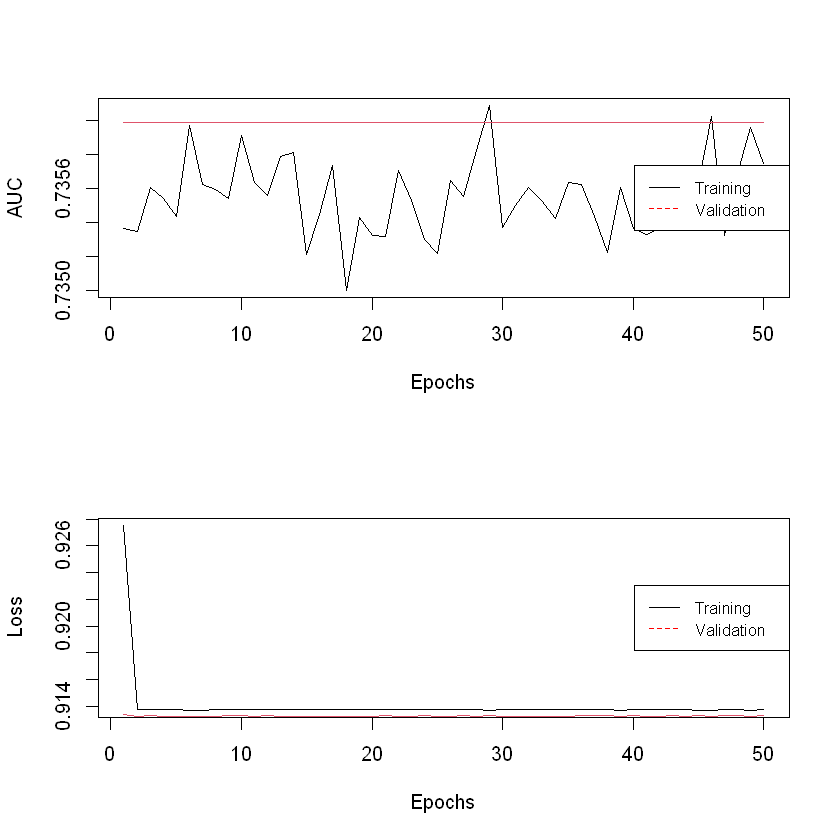

[1] "F1-Score Micro - 4 fold - 50 epochs: 0.569932295584746"
  |======================================================================| 100%

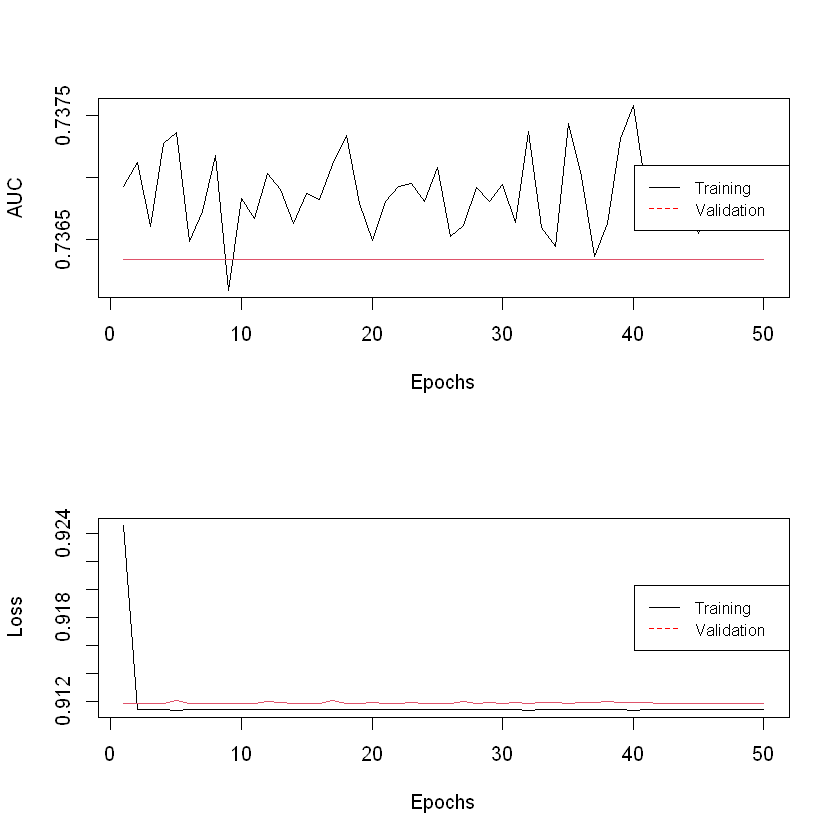

[1] "F1-Score Micro - 5 fold - 50 epochs: 0.565963849611297"


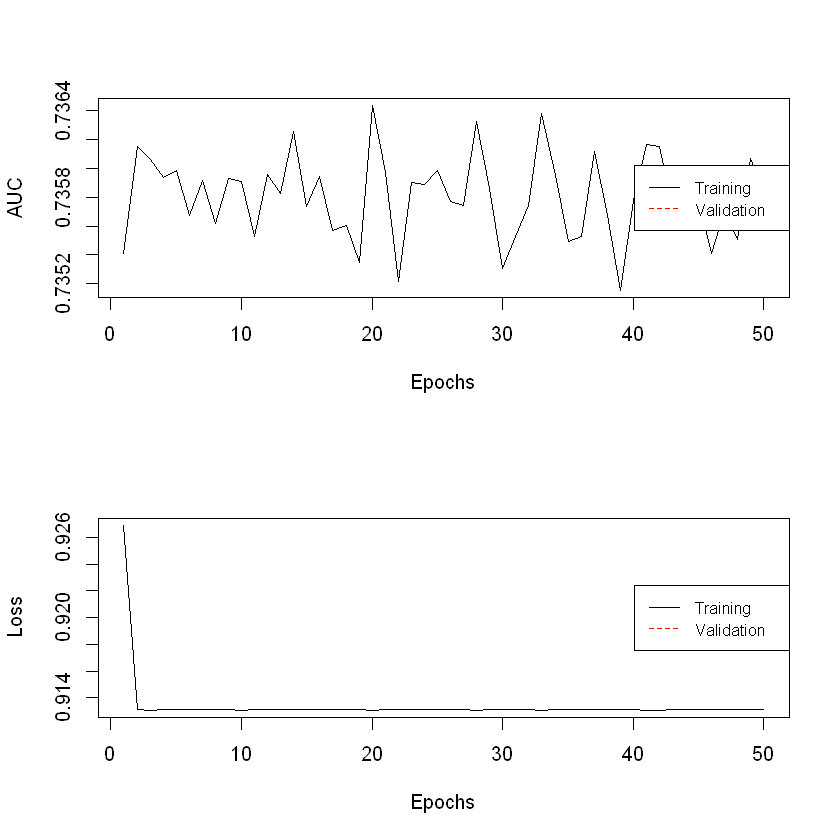

[1] "Mean F1-Score Micro: 0.56879140426055"


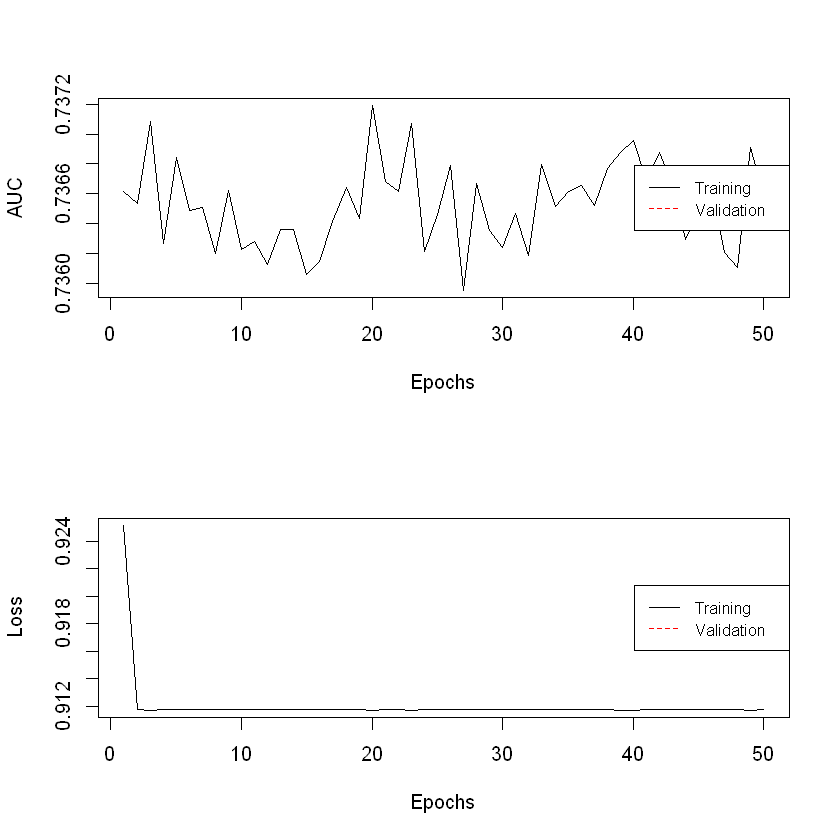

In [6]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(1, activation = 'relu') %>%
    layer_dense(1, activation = 'relu') %>%
    layer_dense(1, activation = 'relu') %>%
    layer_dense(1, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

In [7]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(1, activation = 'relu') %>%
    layer_dense(1, activation = 'relu') %>%
    layer_dense(1, activation = 'relu') %>%
    layer_dense(1, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

  |                                                                      |   0%

ERROR: Error in `[.data.frame`(test_data, i, target_variables): colonnes non définies sélectionnées


In [11]:
yhaty <- classConverter(yhat,test_data)

F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])

[1] 0.5700866

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 50 epochs: 0.755183920683602"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 50 epochs: 0.753872268194356"
  |==========================================                            |  60%

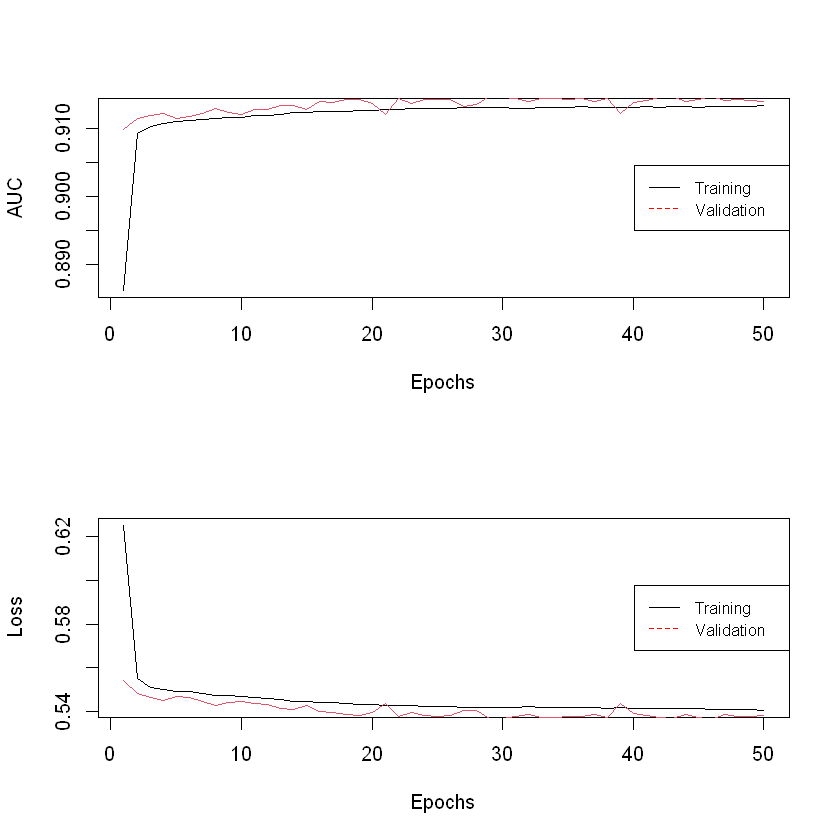

[1] "F1-Score Micro - 3 fold - 50 epochs: 0.751210385201474"
  |========================================================              |  80%

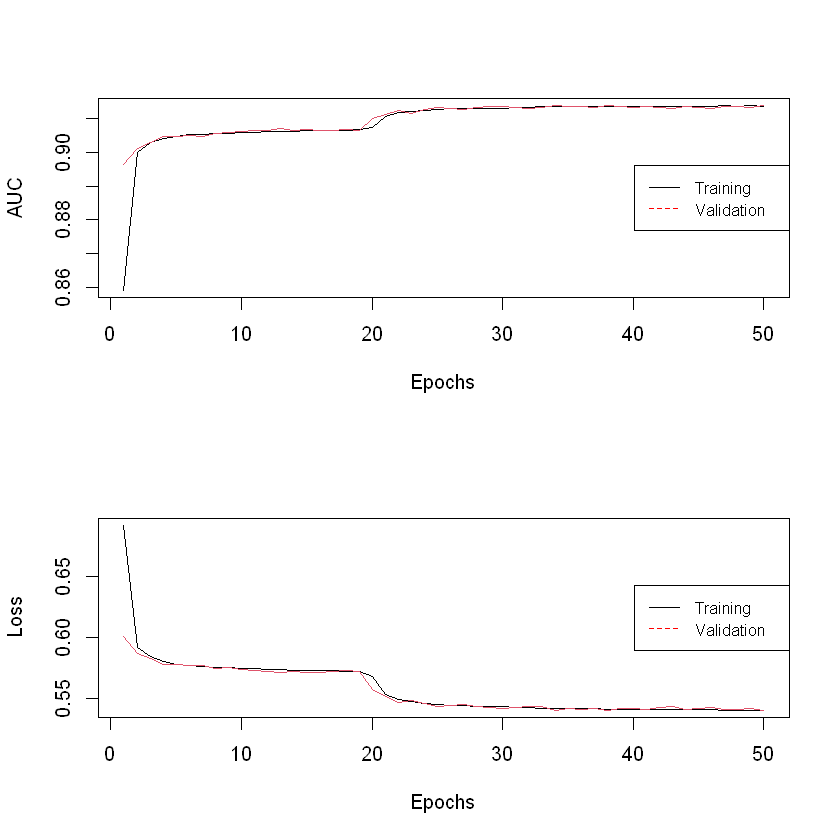

[1] "F1-Score Micro - 4 fold - 50 epochs: 0.752734216769863"
  |======================================================================| 100%

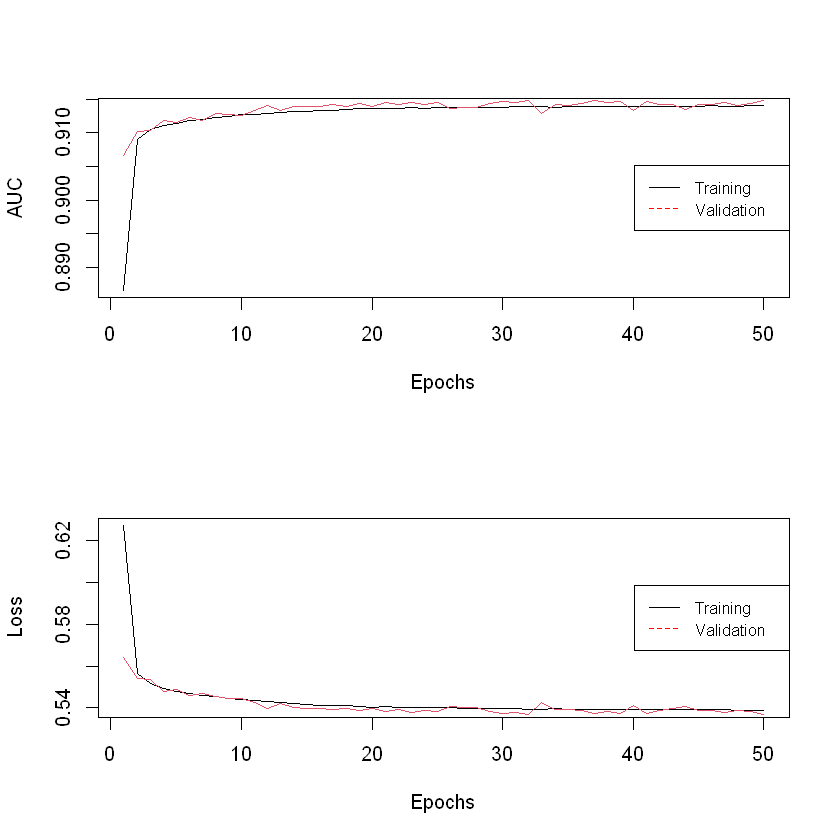

[1] "F1-Score Micro - 5 fold - 50 epochs: 0.755280773163063"


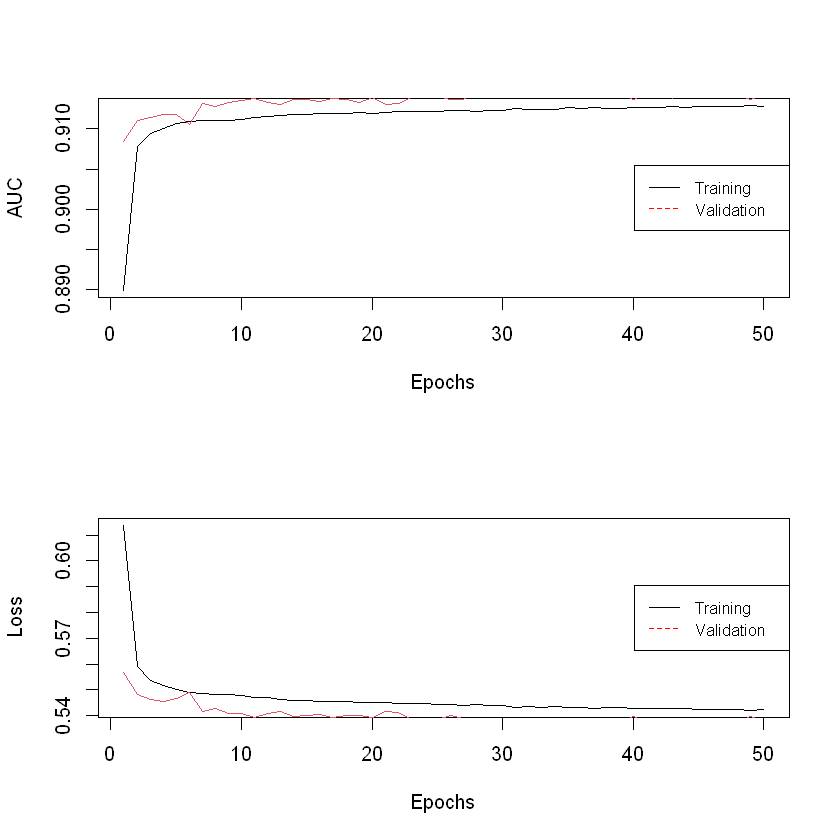

[1] "Mean F1-Score Micro: 0.753656312802471"


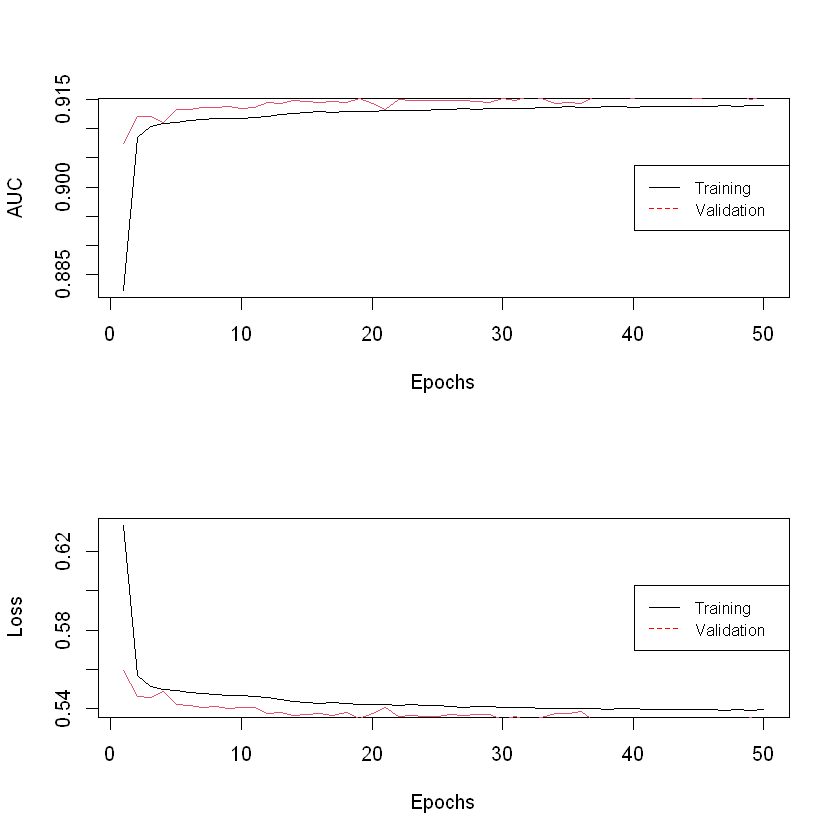

In [12]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(5, activation = 'relu') %>%
    layer_dense(5, activation = 'relu') %>%
    layer_dense(5, activation = 'relu') %>%
    layer_dense(5, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

In [ ]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(5, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 